In [1]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt
from cryo_sbi.utils.infer_populations import generate_population_weights

Install with: conda install conda-forge::numpyro


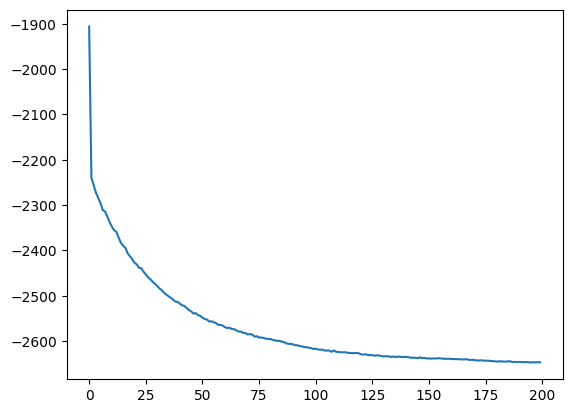

In [2]:
loss = torch.load('tutorial.loss')
plt.plot(loss)
plt.show()

In [3]:
def plot_weights_comparison(x_opt, w_actual, ax):
    """
    Plot comparison between optimized and actual weights with RMSE.
    """

    # Convert to numpy if needed
    if torch.is_tensor(x_opt):
        x_opt = x_opt.detach().cpu().numpy()
    if torch.is_tensor(w_actual):
        w_actual = w_actual.detach().cpu().numpy()

    # Calculate RMSE
    rmse = np.sqrt(np.mean((x_opt - w_actual) ** 2))

    n_mod = len(x_opt)
    model_indexes = np.arange(1, n_mod + 1)
    bar_width = 0.35
    x_pos = np.arange(n_mod)

    # Plot bars
    ax.bar(
        x_pos - bar_width / 2,
        x_opt,
        bar_width,
        label="CryoBear weights",
        color="#3498db",
        alpha=0.8,
        edgecolor="black",
        linewidth=1.2,
    )

    ax.bar(
        x_pos + bar_width / 2,
        w_actual,
        bar_width,
        label="True weights",
        color="#2ecc71",
        alpha=0.8,
        edgecolor="black",
        linewidth=1.2,
    )

    # Styling
    ax.set_xlabel("Model Index", fontsize=11, weight="bold")
    ax.set_ylabel("Weight", fontsize=11, weight="bold")
    ax.set_title(f"RMSE = {rmse:.6f}", fontsize=8, weight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_indexes)
    ax.set_xlim(-0.5, n_mod - 0.5)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    return rmse

In [4]:
w_opt_10k_1 = np.load('10k_opt_w.npy')

w_actual_10k_1 = np.load('10k_a_w.npy')


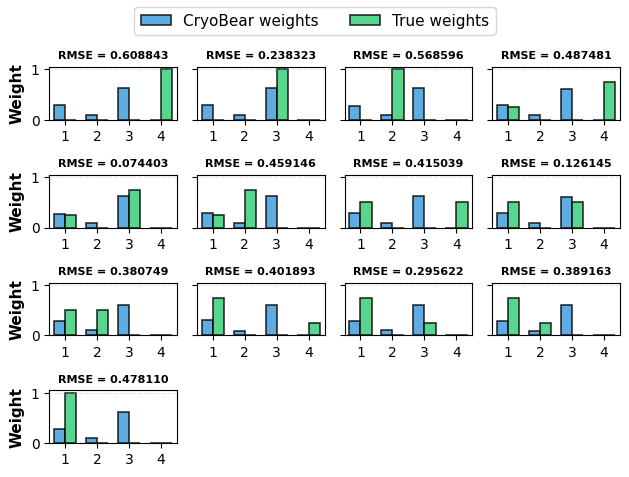

In [5]:
n = len(w_opt_10k_1)   # 13
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    #figsize=(5 * cols, 4 * rows),
    sharey=True
)

axes = axes.flatten()

for i in range(n):
    plot_weights_comparison(
        w_opt_10k_1[i],
        w_actual_10k_1[i],
        axes[i]
    )

# Remove empty subplots
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

# Optional: one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=11
)
for i, ax in enumerate(axes[:n]):
    if i % cols != 0:
        ax.set_ylabel("")
    ax.set_xlabel("")



plt.tight_layout(rect=[0, 0, 1, 0.93])
#plt.savefig('weights_10k.pdf')
plt.show()
